In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

Dataset size: 60000
Image shape: torch.Size([1, 28, 28])


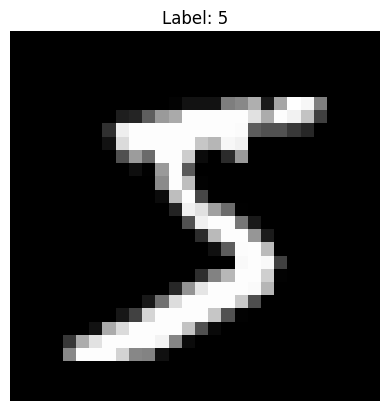

torch.Size([64, 1, 28, 28])
torch.Size([64])
torch.Size([64, 10])


In [9]:
#Earlier

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

print("Dataset size:", len(train_dataset))
print("Image shape:", train_dataset[0][0].shape)

image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")

plt.show()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64)

test_loader = DataLoader(test_dataset, batch_size=64)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

        self.fc = nn.Linear(16 * 14 * 14, 10)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x
    
model = CNN()

images, labels = next(iter(train_loader))

output = model(images)

print(output.shape)


In [10]:
criterion = nn.CrossEntropyLoss()

In [11]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [3]:
def train(model, train_loader, optimizer, criterion):

    model.train()

    total_loss =0

    for batch_idx, (images, labels) in enumerate(train_loader):

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss+=loss.item()

        if batch_idx % 100 == 0:
            print(f"Batch {batch_idx}, Loss: {loss.item():.4f}")

    average_loss= total_loss/len(train_loader)
    return average_loss

In [4]:
def test(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    for images, labels in test_loader:

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(0,predicted.size(0)):
            if predicted[i]==labels[i]:
                correct+=1        
        total+=labels.size(0)

    accuracy=(correct/total)*100
    print(accuracy)
    return accuracy


In [47]:
for epoch in range(5):

    print("Epoch ",epoch+1)

    train(
        model,
        train_loader,
        optimizer,
        criterion
    )

test(
    model,
    test_loader
)

Epoch  1
Batch 0, Loss: 0.0211
Batch 100, Loss: 0.1548
Batch 200, Loss: 0.0408
Batch 300, Loss: 0.0571
Batch 400, Loss: 0.0414
Batch 500, Loss: 0.1343
Batch 600, Loss: 0.0805
Batch 700, Loss: 0.1324
Batch 800, Loss: 0.1168
Batch 900, Loss: 0.0731
Epoch  2
Batch 0, Loss: 0.0478
Batch 100, Loss: 0.1351
Batch 200, Loss: 0.0334
Batch 300, Loss: 0.0537
Batch 400, Loss: 0.0447
Batch 500, Loss: 0.1494
Batch 600, Loss: 0.0713
Batch 700, Loss: 0.1050
Batch 800, Loss: 0.0986
Batch 900, Loss: 0.0626
Epoch  3
Batch 0, Loss: 0.0382
Batch 100, Loss: 0.1147
Batch 200, Loss: 0.0289
Batch 300, Loss: 0.0459
Batch 400, Loss: 0.0464
Batch 500, Loss: 0.1521
Batch 600, Loss: 0.0705
Batch 700, Loss: 0.0848
Batch 800, Loss: 0.0826
Batch 900, Loss: 0.0540
Epoch  4
Batch 0, Loss: 0.0312
Batch 100, Loss: 0.1026
Batch 200, Loss: 0.0256
Batch 300, Loss: 0.0397
Batch 400, Loss: 0.0455
Batch 500, Loss: 0.1460
Batch 600, Loss: 0.0698
Batch 700, Loss: 0.0682
Batch 800, Loss: 0.0692
Batch 900, Loss: 0.0462
Epoch  5
Bat

In [48]:
print("Some more epochs...")

for epoch in range(5):

    print("Epoch ",(5+epoch))

    train(
        model,
        train_loader,
        optimizer,
        criterion
    )

test(
    model,
    test_loader
)

Some more epochs...
Epoch  5
Batch 0, Loss: 0.0208
Batch 100, Loss: 0.0891
Batch 200, Loss: 0.0197
Batch 300, Loss: 0.0376
Batch 400, Loss: 0.0473
Batch 500, Loss: 0.1486
Batch 600, Loss: 0.0516
Batch 700, Loss: 0.0431
Batch 800, Loss: 0.0499
Batch 900, Loss: 0.0346
Epoch  6
Batch 0, Loss: 0.0178
Batch 100, Loss: 0.0772
Batch 200, Loss: 0.0170
Batch 300, Loss: 0.0385
Batch 400, Loss: 0.0496
Batch 500, Loss: 0.1554
Batch 600, Loss: 0.0386
Batch 700, Loss: 0.0347
Batch 800, Loss: 0.0444
Batch 900, Loss: 0.0314
Epoch  7
Batch 0, Loss: 0.0153
Batch 100, Loss: 0.0650
Batch 200, Loss: 0.0160
Batch 300, Loss: 0.0359
Batch 400, Loss: 0.0529
Batch 500, Loss: 0.1535
Batch 600, Loss: 0.0291
Batch 700, Loss: 0.0299
Batch 800, Loss: 0.0391
Batch 900, Loss: 0.0289
Epoch  8
Batch 0, Loss: 0.0134
Batch 100, Loss: 0.0561
Batch 200, Loss: 0.0168
Batch 300, Loss: 0.0334
Batch 400, Loss: 0.0526
Batch 500, Loss: 0.1511
Batch 600, Loss: 0.0219
Batch 700, Loss: 0.0283
Batch 800, Loss: 0.0317
Batch 900, Loss:

In [52]:
model = CNN()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

for epoch in range(5):
    print("Epoch", epoch+1)
    train(model, train_loader, optimizer, criterion)

test(model, test_loader)

Epoch 1
Batch 0, Loss: 2.4230
Batch 100, Loss: 0.2946
Batch 200, Loss: 0.2485
Batch 300, Loss: 0.2327
Batch 400, Loss: 0.1114
Batch 500, Loss: 0.2964
Batch 600, Loss: 0.1120
Batch 700, Loss: 0.2918
Batch 800, Loss: 0.2574
Batch 900, Loss: 0.1941
Epoch 2
Batch 0, Loss: 0.1135
Batch 100, Loss: 0.1495
Batch 200, Loss: 0.0765
Batch 300, Loss: 0.1099
Batch 400, Loss: 0.0525
Batch 500, Loss: 0.1595
Batch 600, Loss: 0.0764
Batch 700, Loss: 0.1835
Batch 800, Loss: 0.1420
Batch 900, Loss: 0.1225
Epoch 3
Batch 0, Loss: 0.0841
Batch 100, Loss: 0.1337
Batch 200, Loss: 0.0547
Batch 300, Loss: 0.0725
Batch 400, Loss: 0.0394
Batch 500, Loss: 0.1090
Batch 600, Loss: 0.0812
Batch 700, Loss: 0.1533
Batch 800, Loss: 0.1172
Batch 900, Loss: 0.0903
Epoch 4
Batch 0, Loss: 0.0534
Batch 100, Loss: 0.1237
Batch 200, Loss: 0.0403
Batch 300, Loss: 0.0481
Batch 400, Loss: 0.0375
Batch 500, Loss: 0.0929
Batch 600, Loss: 0.0774
Batch 700, Loss: 0.1258
Batch 800, Loss: 0.1062
Batch 900, Loss: 0.0783
Epoch 5
Batch 0,

In [53]:
for epoch in range(3):

    print("Extra Epoch", epoch + 1)

    train(
        model,
        train_loader,
        optimizer,
        criterion
    )

test(
    model,
    test_loader
)

Extra Epoch 1
Batch 0, Loss: 0.0207
Batch 100, Loss: 0.1091
Batch 200, Loss: 0.0265
Batch 300, Loss: 0.0305
Batch 400, Loss: 0.0331
Batch 500, Loss: 0.0694
Batch 600, Loss: 0.0670
Batch 700, Loss: 0.0620
Batch 800, Loss: 0.0943
Batch 900, Loss: 0.0637
Extra Epoch 2
Batch 0, Loss: 0.0149
Batch 100, Loss: 0.1012
Batch 200, Loss: 0.0218
Batch 300, Loss: 0.0284
Batch 400, Loss: 0.0293
Batch 500, Loss: 0.0658
Batch 600, Loss: 0.0591
Batch 700, Loss: 0.0402
Batch 800, Loss: 0.0863
Batch 900, Loss: 0.0536
Extra Epoch 3
Batch 0, Loss: 0.0119
Batch 100, Loss: 0.0912
Batch 200, Loss: 0.0178
Batch 300, Loss: 0.0262
Batch 400, Loss: 0.0251
Batch 500, Loss: 0.0644
Batch 600, Loss: 0.0533
Batch 700, Loss: 0.0260
Batch 800, Loss: 0.0752
Batch 900, Loss: 0.0412
98.13


In [54]:
torch.save(
    model.state_dict(),
    "mnist_cnn.pt"
)

print("Model saved")

Model saved


In [55]:
loaded_model = CNN()

loaded_model.load_state_dict(
    torch.load("mnist_cnn.pt")
)

loaded_model.eval()

print("Model loaded")

Model loaded


In [56]:
image, label = test_dataset[0]

with torch.no_grad():

    output = loaded_model(
        image.unsqueeze(0)
    )

    _, prediction = torch.max(output, 1)

print("Actual:", label)
print("Predicted:", prediction.item())

Actual: 7
Predicted: 7


In [13]:
model = CNN()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

loss_history = []
accuracy_history = []

for epoch in range(10):

    print("Epoch ",epoch+1)

    loss = train(
        model,
        train_loader,
        optimizer,
        criterion
    )

    accuracy = test(
        model,
        test_loader
    )

    loss_history.append(loss)
    accuracy_history.append(accuracy)

Epoch  1
Batch 0, Loss: 2.3354
Batch 100, Loss: 0.2872
Batch 200, Loss: 0.2282
Batch 300, Loss: 0.1955
Batch 400, Loss: 0.1063
Batch 500, Loss: 0.2426
Batch 600, Loss: 0.0932
Batch 700, Loss: 0.2860
Batch 800, Loss: 0.2851
Batch 900, Loss: 0.2022
96.3
Epoch  2
Batch 0, Loss: 0.1202
Batch 100, Loss: 0.1673
Batch 200, Loss: 0.0687
Batch 300, Loss: 0.0986
Batch 400, Loss: 0.0564
Batch 500, Loss: 0.1291
Batch 600, Loss: 0.0544
Batch 700, Loss: 0.1745
Batch 800, Loss: 0.1691
Batch 900, Loss: 0.1100
97.18
Epoch  3
Batch 0, Loss: 0.0821
Batch 100, Loss: 0.1611
Batch 200, Loss: 0.0447
Batch 300, Loss: 0.0598
Batch 400, Loss: 0.0489
Batch 500, Loss: 0.0971
Batch 600, Loss: 0.0504
Batch 700, Loss: 0.1481
Batch 800, Loss: 0.1430
Batch 900, Loss: 0.0766
97.58
Epoch  4
Batch 0, Loss: 0.0581
Batch 100, Loss: 0.1540
Batch 200, Loss: 0.0298
Batch 300, Loss: 0.0431
Batch 400, Loss: 0.0437
Batch 500, Loss: 0.0775
Batch 600, Loss: 0.0490
Batch 700, Loss: 0.1320
Batch 800, Loss: 0.1394
Batch 900, Loss: 0.

In [14]:
for epoch in range(10):

    print("Epoch ",epoch+1)

    loss = train(
        model,
        train_loader,
        optimizer,
        criterion
    )

    accuracy = test(
        model,
        test_loader
    )

    loss_history.append(loss)
    accuracy_history.append(accuracy)

Epoch  1
Batch 0, Loss: 0.0124
Batch 100, Loss: 0.0322
Batch 200, Loss: 0.0151
Batch 300, Loss: 0.0197
Batch 400, Loss: 0.0159
Batch 500, Loss: 0.0237
Batch 600, Loss: 0.0408
Batch 700, Loss: 0.0513
Batch 800, Loss: 0.0652
Batch 900, Loss: 0.0138
97.92
Epoch  2
Batch 0, Loss: 0.0122
Batch 100, Loss: 0.0209
Batch 200, Loss: 0.0145
Batch 300, Loss: 0.0187
Batch 400, Loss: 0.0114
Batch 500, Loss: 0.0187
Batch 600, Loss: 0.0301
Batch 700, Loss: 0.0444
Batch 800, Loss: 0.0462
Batch 900, Loss: 0.0139
97.91
Epoch  3
Batch 0, Loss: 0.0117
Batch 100, Loss: 0.0178
Batch 200, Loss: 0.0135
Batch 300, Loss: 0.0188
Batch 400, Loss: 0.0086
Batch 500, Loss: 0.0144
Batch 600, Loss: 0.0111
Batch 700, Loss: 0.0408
Batch 800, Loss: 0.0348
Batch 900, Loss: 0.0142
97.85000000000001
Epoch  4
Batch 0, Loss: 0.0115
Batch 100, Loss: 0.0179
Batch 200, Loss: 0.0127
Batch 300, Loss: 0.0169
Batch 400, Loss: 0.0070
Batch 500, Loss: 0.0152
Batch 600, Loss: 0.0060
Batch 700, Loss: 0.0291
Batch 800, Loss: 0.0309
Batch 

In [15]:
print(loss_history)
print(accuracy_history)

[0.2329597690923096, 0.09486228903097266, 0.0707714516615648, 0.058177471157599754, 0.049357684627761134, 0.04264958124848078, 0.03726566073920718, 0.03266778961869641, 0.028639322982709506, 0.025090955363405096, 0.021969828396915955, 0.018984675486219613, 0.0162947197798032, 0.01399971463943773, 0.012543232433079747, 0.012053955836612026, 0.009991412956626677, 0.008844479243904402, 0.007608487012357669, 0.007319285191574626]
[96.3, 97.18, 97.58, 97.8, 97.89, 97.89999999999999, 97.91, 97.89999999999999, 97.92, 97.89, 97.92, 97.91, 97.85000000000001, 97.71, 97.75, 97.69, 97.63, 97.7, 97.83, 97.92999999999999]


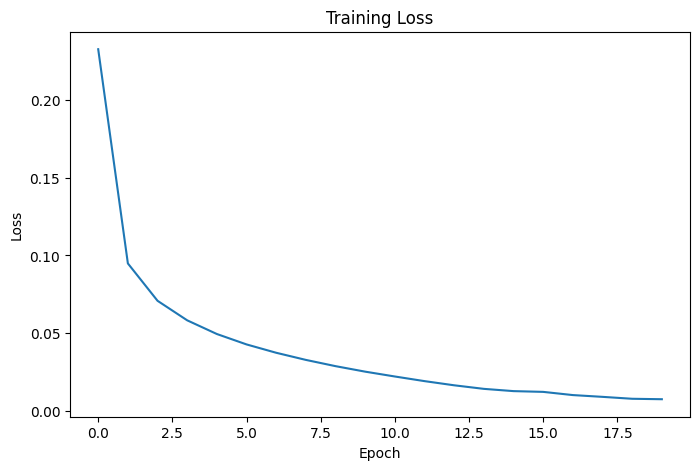

In [17]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

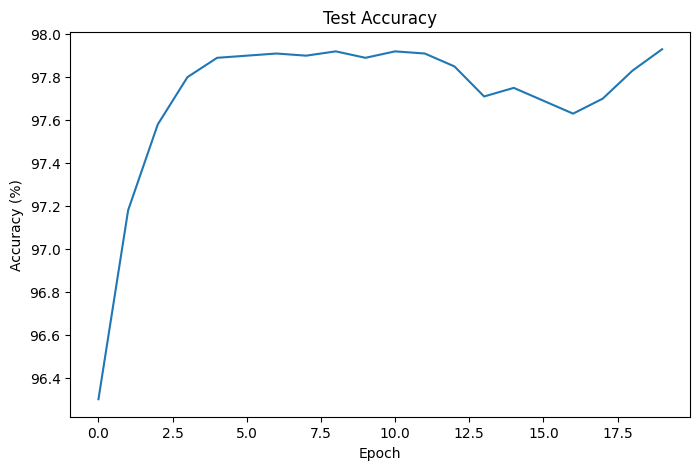

In [18]:
plt.figure(figsize=(8,5))

plt.plot(accuracy_history)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy")

plt.show()